# **Creating Dataframe**

In [ ]:
# Loading essential libraries
import numpy as np
import pandas as pd

In [ ]:
# Loading both of uploaded datasets
fake_df = pd.read_csv('/content/Fake.csv')
true_df = pd.read_csv('/content/True.csv')

fake_df['label'] = 1  # 1 means Fake News
true_df['label'] = 0  # 0 means Real News

# Glues both tables together into one big dataset
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffling the rows randomly so the model gets a mix of real and fake news
df = df.sample(frac=1, random_state=0).reset_index(drop=True)

# **Exploring the dataset**

In [ ]:
df.shape

(44898, 5)

In [ ]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [ ]:
df.head()

,title,text,subject,date,label
0,Ex-Interpol chief says ready to testify for Ar...,BUENOS AIRES (Reuters) - Argentina s previous ...,worldnews,"December 20, 2017",0
1,U.S. warns North Korea of 'overwhelming' respo...,SEOUL (Reuters) - U.S. President Donald Trump’...,politicsNews,"February 3, 2017",0
2,Big security risks in Trump feud with spy agen...,WASHINGTON (Reuters) - An unprecedented pre-pr...,politicsNews,"January 13, 2017",0
3,France puts suspected militant under investiga...,PARIS (Reuters) - A suspected Islamist militan...,worldnews,"November 15, 2017",0
4,Rudy Giuliani Turns Into A Blithering Idiot W...,During a live CNN interview with Rudy Giuliani...,News,"August 11, 2016",1


In [ ]:
# Importing essential libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Count')

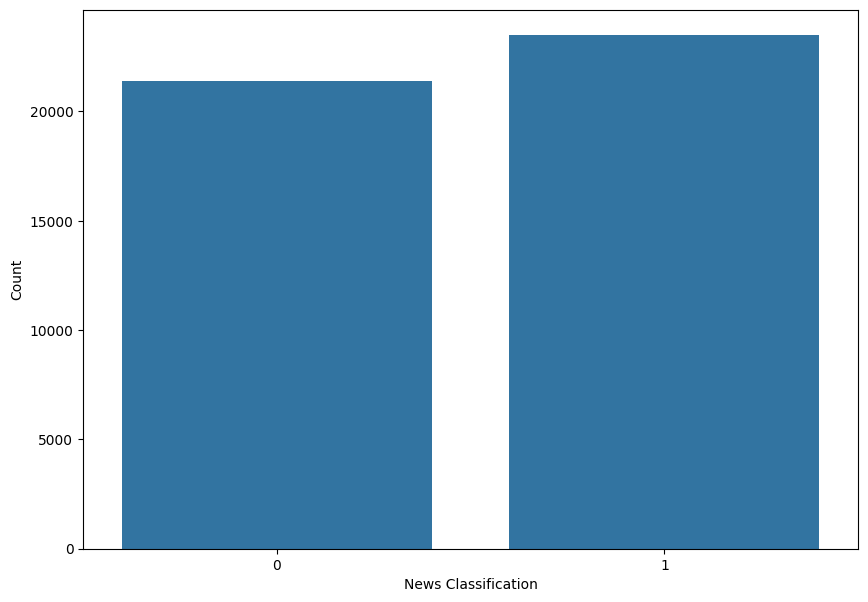

In [ ]:
# Visualizing the count of 'fake news' in the dataset
plt.figure(figsize=(10,7))
sns.countplot(x='label', data=df)
plt.xlabel('News Classification')
plt.ylabel('Count')

# **Data Cleaning and Preprocessing**

In [ ]:
print(df.shape)

(44898, 5)


In [ ]:
# Dropping NaN values
df.dropna(inplace=True)
print(df.shape)

(44898, 5)


In [ ]:
news = df.copy()

In [ ]:
news.reset_index(inplace=True)

In [ ]:
# Importing essential libraries for performing Natural Language Processing on 'kaggle_fake_train' dataset
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Cleaning the news
corpus = []
ps = PorterStemmer()

for i in range(0,news.shape[0]):

  # Cleaning special character from the news-title
  title = re.sub(pattern='[^a-zA-Z]', repl=' ', string=news.title[i])

  # Converting the entire news-title to lower case
  title = title.lower()

  # Tokenizing the news-title by words
  words = title.split()

  # Removing the stopwords
  words = [word for word in words if word not in set(stopwords.words('english'))]

  # Stemming the words
  words = [ps.stem(word) for word in words]

  # Joining the stemmed words
  title = ' '.join(words)

  # Building a corpus of news-title
  corpus.append(title)

In [ ]:
corpus[0:10]

['ex interpol chief say readi testifi argentina fernandez',
 'u warn north korea overwhelm respons nuclear arm use',
 'big secur risk trump feud spi agenc offici say',
 'franc put suspect milit investig kidnap journalist',
 'rudi giuliani turn blither idiot confront cnn host video',
 'carl bernstein donald trump fascist strongman patholog liar video',
 'sean spicer said dumbest thing obama fourth term offic video',
 'grow feud trump cruz escal attack',
 'lou dobb say think trump unexpect patienc fool parti video',
 'trump vs clinton debat mark biggest moment elect']

In [ ]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000, ngram_range=(1,3))
X = cv.fit_transform(corpus)

In [ ]:
X.shape

(44898, 5000)

In [ ]:
X[0:10]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 87 stored elements and shape (10, 5000)>

In [ ]:
# Extracting dependent variable from the dataset
y = news['label']

# **Model Building**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

## *Multinomial Naive Bayes*

In [ ]:
# Fitting Naive Bayes to the Training set
from sklearn.naive_bayes import MultinomialNB
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Predicting the Test set results
nb_y_pred = nb_classifier.predict(X_test)

In [ ]:
# Accuracy, Precision and Recall
from sklearn.metrics import accuracy_score, precision_score, recall_score
score1 = accuracy_score(y_test, nb_y_pred)
score2 = precision_score(y_test, nb_y_pred)
score3 = recall_score(y_test, nb_y_pred)
print("---- Scores ----")
print("Accuracy score is: {}%".format(round(score1*100,2)))
print("Precision score is: {}".format(round(score2,2)))
print("Recall score is: {}".format(round(score3,2)))

---- Scores ----
Accuracy score is: 93.36%
Precision score is: 0.93
Recall score is: 0.95


In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
nb_cm = confusion_matrix(y_test, nb_y_pred)

In [ ]:
nb_cm

array([[3977,  345],
       [ 251, 4407]])

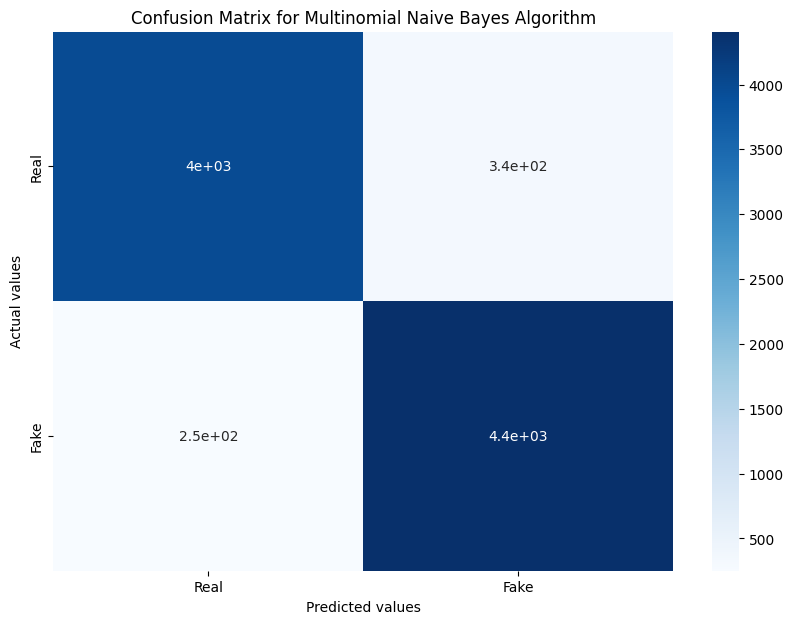

In [ ]:
# Plotting the confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(data=nb_cm, annot=True, cmap="Blues", xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix for Multinomial Naive Bayes Algorithm')
plt.show()

In [ ]:
# Hyperparameter tuning the Naive Bayes Classifier
best_accuracy = 0.0
alpha_val = 0.0
for i in np.arange(0.1,1.1,0.1):
  temp_classifier = MultinomialNB(alpha=i)
  temp_classifier.fit(X_train, y_train)
  temp_y_pred = temp_classifier.predict(X_test)
  score = accuracy_score(y_test, temp_y_pred)
  print("Accuracy score for alpha={} is: {}%".format(round(i,1), round(score*100,2)))
  if score>best_accuracy:
    best_accuracy = score
    alpha_val = i
print('--------------------------------------------')
print('The best accuracy is {}% with alpha value as {}'.format(round(best_accuracy*100, 2), round(alpha_val,1)))

Accuracy score for alpha=0.1 is: 93.37%
Accuracy score for alpha=0.2 is: 93.34%
Accuracy score for alpha=0.3 is: 93.32%
Accuracy score for alpha=0.4 is: 93.31%
Accuracy score for alpha=0.5 is: 93.35%
Accuracy score for alpha=0.6 is: 93.32%
Accuracy score for alpha=0.7 is: 93.37%
Accuracy score for alpha=0.8 is: 93.36%
Accuracy score for alpha=0.9 is: 93.36%
Accuracy score for alpha=1.0 is: 93.36%
--------------------------------------------
The best accuracy is 93.37% with alpha value as 0.1


## *Logistic Regression*

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_classifier = LogisticRegression(random_state=0)
lr_classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
# Predicting the Test set results
lr_y_pred = lr_classifier.predict(X_test)

In [ ]:
# Accuracy, Precision and Recall
from sklearn.metrics import accuracy_score, precision_score, recall_score
score1 = accuracy_score(y_test, lr_y_pred)
score2 = precision_score(y_test, lr_y_pred)
score3 = recall_score(y_test, lr_y_pred)
print("---- Scores ----")
print("Accuracy score is: {}%".format(round(score1*100,2)))
print("Precision score is: {}".format(round(score2,2)))
print("Recall score is: {}".format(round(score3,2)))

---- Scores ----
Accuracy score is: 95.02%
Precision score is: 0.96
Recall score is: 0.94


In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
lr_cm = confusion_matrix(y_test, lr_y_pred)

In [ ]:
lr_cm

array([[4133,  189],
       [ 258, 4400]])

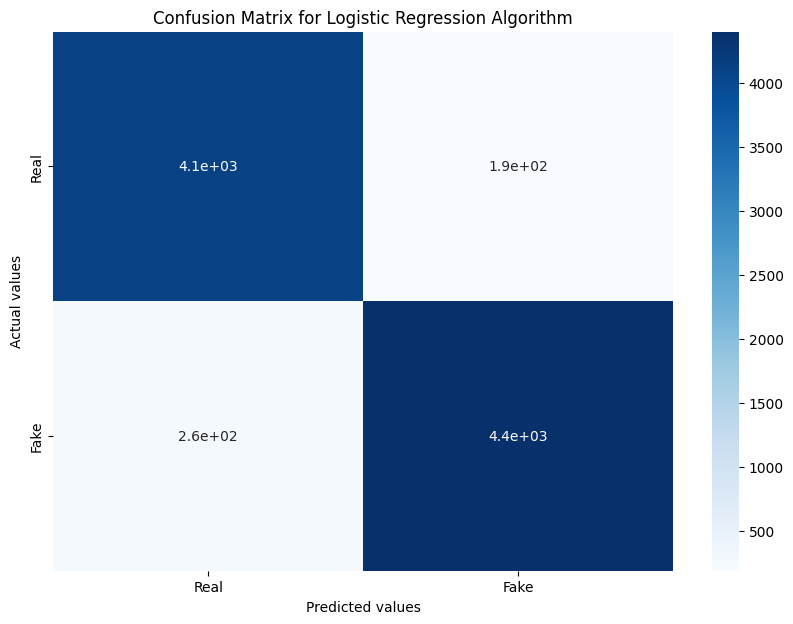

In [ ]:
# Plotting the confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(data=lr_cm, annot=True, cmap="Blues", xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix for Logistic Regression Algorithm')
plt.show()

In [ ]:
# Hyperparameter tuning the Logistic Regression Classifier
best_accuracy = 0.0
c_val = 0.0
for i in np.arange(0.1,1.1,0.1):
  temp_classifier = LogisticRegression(C=i, random_state=0)
  temp_classifier.fit(X_train, y_train)
  temp_y_pred = temp_classifier.predict(X_test)
  score = accuracy_score(y_test, temp_y_pred)
  print("Accuracy score for C={} is: {}%".format(round(i,1), round(score*100,2)))
  if score>best_accuracy:
    best_accuracy = score
    c_val = i
print('--------------------------------------------')
print('The best accuracy is {}% with C value as {}'.format(round(best_accuracy*100, 2), round(c_val,1)))

Accuracy score for C=0.1 is: 93.75%
Accuracy score for C=0.2 is: 94.27%
Accuracy score for C=0.3 is: 94.47%
Accuracy score for C=0.4 is: 94.61%
Accuracy score for C=0.5 is: 94.64%
Accuracy score for C=0.6 is: 94.79%
Accuracy score for C=0.7 is: 94.98%
Accuracy score for C=0.8 is: 94.99%
Accuracy score for C=0.9 is: 95.0%
Accuracy score for C=1.0 is: 95.02%
--------------------------------------------
The best accuracy is 95.02% with C value as 1.0


In [ ]:
classifier = LogisticRegression(C=0.8, random_state=0)
classifier.fit(X_train, y_train)

LogisticRegression(C=0.8, random_state=0)

# **Predictions**

In [ ]:
def fake_news(sample_news):
  sample_news = re.sub(pattern='[^a-zA-Z]',repl=' ', string=sample_news)
  sample_news = sample_news.lower()
  sample_news_words = sample_news.split()
  sample_news_words = [word for word in sample_news_words if not word in set(stopwords.words('english'))]
  ps = PorterStemmer()
  final_news = [ps.stem(word) for word in sample_news_words]
  final_news = ' '.join(final_news)

  temp = cv.transform([final_news]).toarray()
  return classifier.predict(temp)

In [ ]:
from random import randint

unseen_test_headlines = [corpus[i] for i in y_test.index]

print(f"Successfully loaded {len(unseen_test_headlines)} pure test headlines for prediction verification.\n")
print("=" * 60)

# Running 4 random test predictions from your new dataset
for i in range(1, 5):
    # Picking a random index from our unseen test pool
    random_row = randint(0, len(unseen_test_headlines) - 1)
    sample_news = unseen_test_headlines[random_row]

    print(f"Test Run #{i}")
    print(f"News Title: {sample_news}")

    # Passing the unseen title to our model pipeline
    if fake_news(sample_news):
        print('Prediction: This is a FAKE news! ')
    else:
        print('Prediction: This is a REAL news.  ')

    print("-" * 60)

Successfully loaded 8980 pure test headlines for prediction verification.

Test Run #1
News Title: matti reaffirm u allianc japan year come
Prediction: This is a REAL news.  
------------------------------------------------------------
Test Run #2
News Title: shakedown al sharpton meet gm pressur drop kid rock confederatef flag video
Prediction: This is a FAKE news! 
------------------------------------------------------------
Test Run #3
News Title: judg napolitano three intel sourc disclos obama spi trump video
Prediction: This is a FAKE news! 
------------------------------------------------------------
Test Run #4
News Title: video hillari channel southern drawl address black democrat alabama plu throwback video bonu hillari accent evolut
Prediction: This is a FAKE news! 
------------------------------------------------------------
